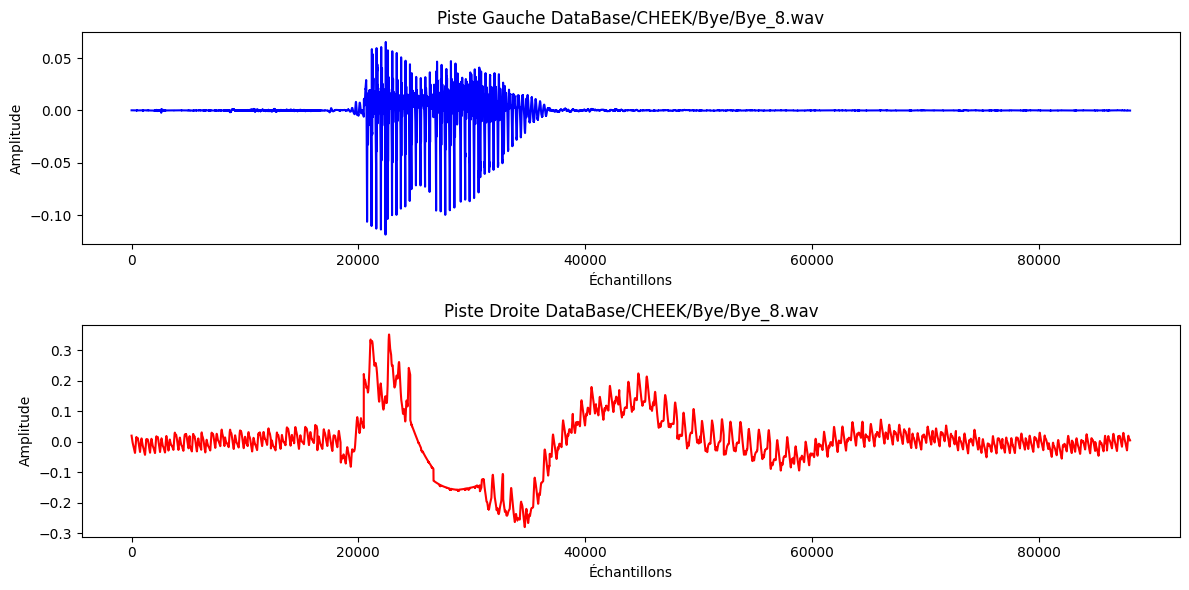

In [71]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Charger le fichier audio (stéréo)
file_path = "DataBase/CHEEK/Bye/Bye_8.wav"
audio, fs = librosa.load(file_path, sr=None, mono=False)  # mono=False pour charger en stéréo

# Vérifier si l'audio est bien stéréo
if audio.ndim == 2:
    left_channel = audio[0, :]  # Piste gauche
    right_channel = audio[1, :]  # Piste droite

    # Tracé des pistes dans deux fenêtres séparées
    plt.figure(figsize=(12, 6))
    

    # Piste gauche
    plt.subplot(2, 1, 1)
    plt.plot(left_channel, color="blue")
    plt.title("Piste Gauche "+ file_path)
    plt.xlabel("Échantillons")
    plt.ylabel("Amplitude")

    # Piste droite
    plt.subplot(2, 1, 2)
    plt.plot(right_channel, color="red")
    plt.title("Piste Droite "+ file_path)
    plt.xlabel("Échantillons")
    plt.ylabel("Amplitude")

    plt.tight_layout()
    
    plt.show()

else:
    print("Le fichier audio n'est pas stéréo.")


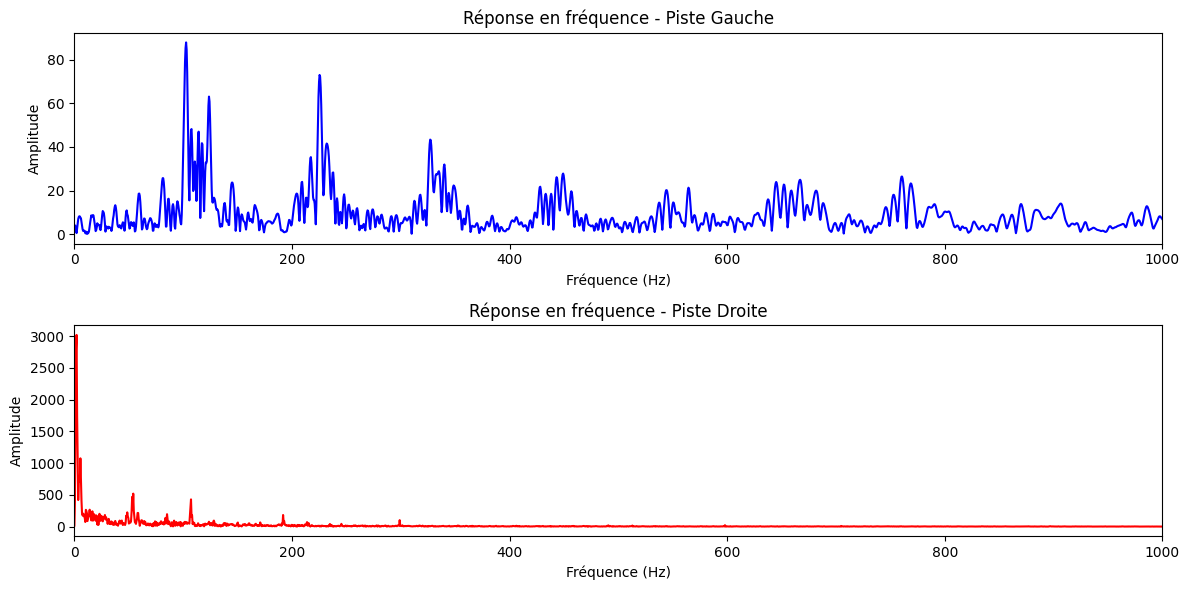

In [72]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Calcul de la FFT
freq = np.fft.rfftfreq(len(left_channel), d=1/fs)
fft_left = np.abs(np.fft.rfft(left_channel))
fft_right = np.abs(np.fft.rfft(right_channel))

# Tracé des réponses en fréquence
plt.figure(figsize=(12, 6))

# Piste gauche
plt.subplot(2, 1, 1)
plt.plot(freq, fft_left, color="blue")
plt.title("Réponse en fréquence - Piste Gauche")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.xlim([0,1000])  # Limite jusqu'à la fréquence de Nyquist

# Piste droite
plt.subplot(2, 1, 2)
plt.plot(freq, fft_right, color="red")
plt.title("Réponse en fréquence - Piste Droite")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.xlim([0,1000])

plt.tight_layout()
plt.show()


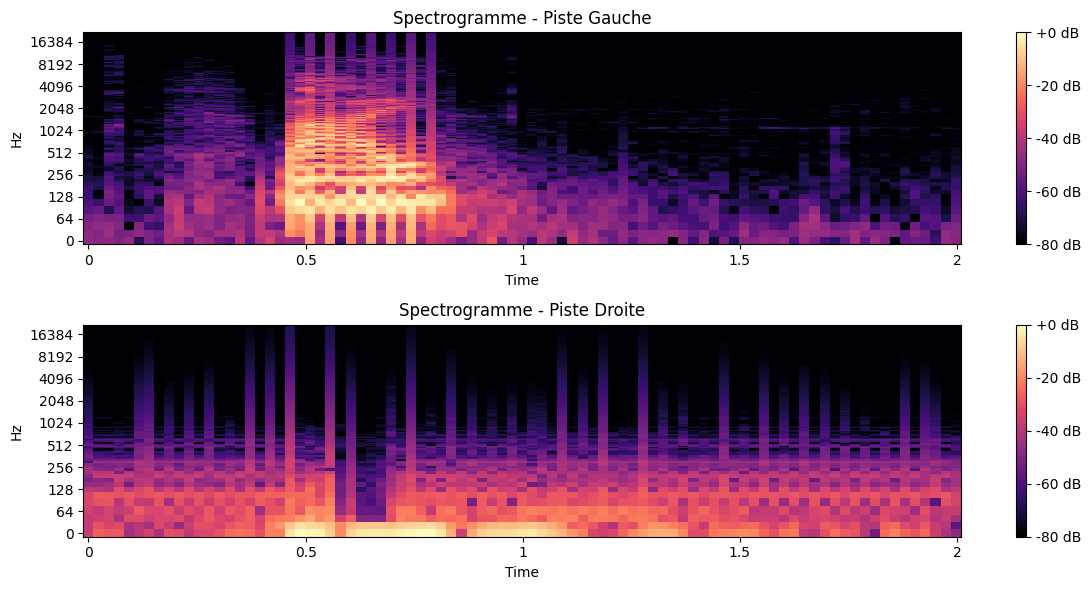

In [73]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Calcul de la STFT
n_fft = 2048  # Taille de la fenêtre FFT
hop_length = 1024  # Décalage entre les fenêtres

stft_left = np.abs(librosa.stft(left_channel, n_fft=n_fft, hop_length=hop_length))
stft_right = np.abs(librosa.stft(right_channel, n_fft=n_fft, hop_length=hop_length))

# Conversion en échelle logarithmique
stft_left_db = librosa.amplitude_to_db(stft_left, ref=np.max)
stft_right_db = librosa.amplitude_to_db(stft_right, ref=np.max)

# Tracé des spectrogrammes
plt.figure(figsize=(12, 6))

# Piste gauche
plt.subplot(2, 1, 1)
librosa.display.specshow(stft_left_db, sr=fs, hop_length=hop_length, x_axis='time', y_axis='log')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogramme - Piste Gauche")

# Piste droite
plt.subplot(2, 1, 2)
librosa.display.specshow(stft_right_db, sr=fs, hop_length=hop_length, x_axis='time', y_axis='log')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogramme - Piste Droite")

plt.tight_layout()
plt.show()




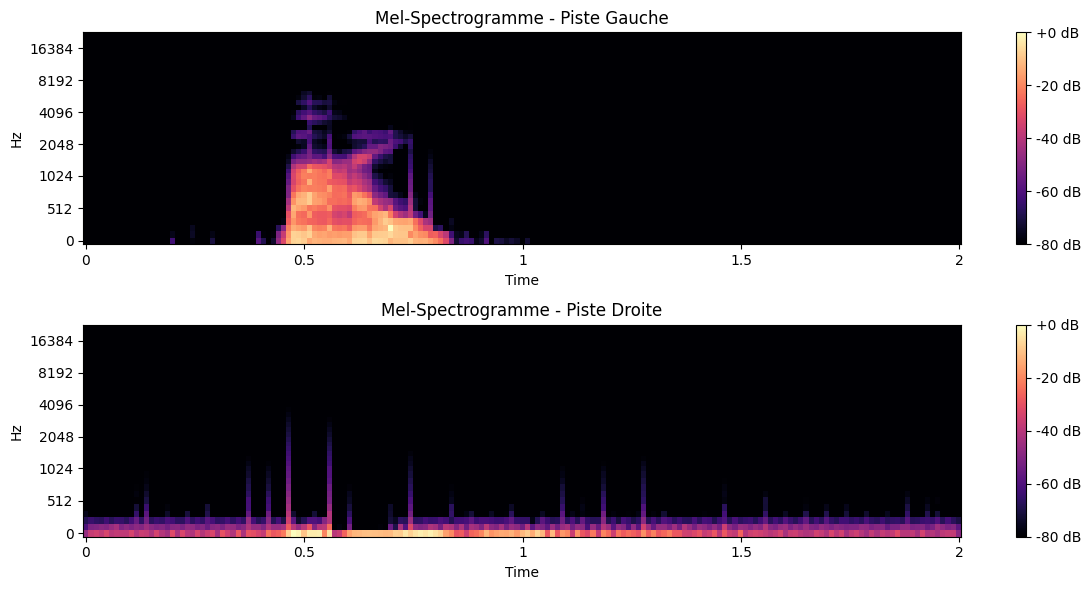

In [74]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display


# Paramètres STFT
n_fft = 1024  # Taille de la fenêtre FFT
hop_length = 512  # Décalage entre les fenêtres

# Calcul du Mel-spectrogramme
n_mels = 40
mel_left = librosa.feature.melspectrogram(y=left_channel, sr=fs, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
mel_right = librosa.feature.melspectrogram(y=right_channel, sr=fs, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)

# Conversion en échelle logarithmique
mel_left_db = librosa.amplitude_to_db(mel_left, ref=np.max)
mel_right_db = librosa.amplitude_to_db(mel_right, ref=np.max)

# Tracé des Mel-spectrogrammes
plt.figure(figsize=(12, 6))

# Piste gauche
plt.subplot(2, 1, 1)
librosa.display.specshow(mel_left_db, sr=fs, hop_length=hop_length, x_axis='time', y_axis='mel')
plt.colorbar(format="%+2.0f dB")
plt.title("Mel-Spectrogramme - Piste Gauche")

# Piste droite
plt.subplot(2, 1, 2)
librosa.display.specshow(mel_right_db, sr=fs, hop_length=hop_length, x_axis='time', y_axis='mel')
plt.colorbar(format="%+2.0f dB")
plt.title("Mel-Spectrogramme - Piste Droite")

plt.tight_layout()
plt.show()